In [111]:
import requests
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

API_URL = "http://localhost:3005/api/ticker/get"

def get_available_tickers():
    response = requests.get(f"{API_URL}/available")
    return response.json()

def get_thirtymin_ticker(url, ticker):
    response = requests.get(f"{url}/thirtymin/{ticker}")
    data = response.json()
    return data

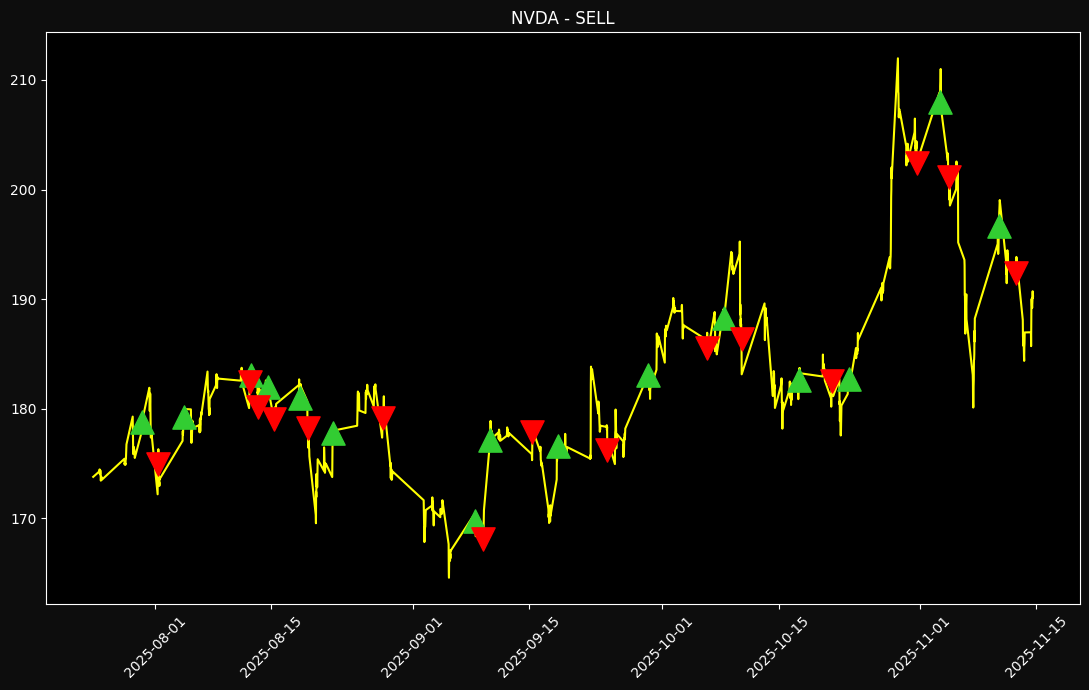

In [ ]:
tickers = get_available_tickers()



data = get_thirtymin_ticker(API_URL, tickers[0])

df = pd.DataFrame(data)
df['datetime'] = pd.to_datetime(df['datetime'])
df["mavg1"] = df["close"].rolling(window=92).mean()
df["mavg2"] = df["close"].rolling(window=46).mean()

df["signal"] = np.where(df["mavg1"] > df["mavg2"], 1, 0)
df["cross"] = df["signal"].diff()

# Last crossing signal
cross_rows = df[df["cross"].isin([1, -1])]
if not cross_rows.empty:
    last_cross = cross_rows.iloc[-1]["cross"]
    heading = "BUY" if last_cross == 1 else "SELL"
else:
    heading = "NO SIGNAL"

# Identify all golden/death crosses
golden = df[df["cross"] == 1]
death = df[df["cross"] == -1]


plt.style.use("dark_background")

plt.figure(figsize=(11, 7), facecolor="#0d0d0d")
plt.plot(df['datetime'], df['close'], linewidth=1.5, color="yellow", zorder=3)
#plt.plot(df["datetime"], df["mavg1"], linewidth=1, color="green", zorder=1)
#plt.plot(df["datetime"], df["mavg2"], linewidth=1, color="yellow", zorder=2)

# Add crossover markers
plt.scatter(golden["datetime"], golden["close"], marker="^", color="limegreen", s=280, label="Golden Cross", zorder=4)
plt.scatter(death["datetime"], death["close"], marker="v", color="red", s=280, label="Death Cross", zorder=4)


plt.title(f"{tickers[0]} - {heading}")

plt.xticks(rotation=45)
plt.tight_layout()



plt.show()
